#2. Random Walk on Networks

1(a)

Connected: True
Nodes: 900 | Edges: 6075 | Mean degree: 13.500


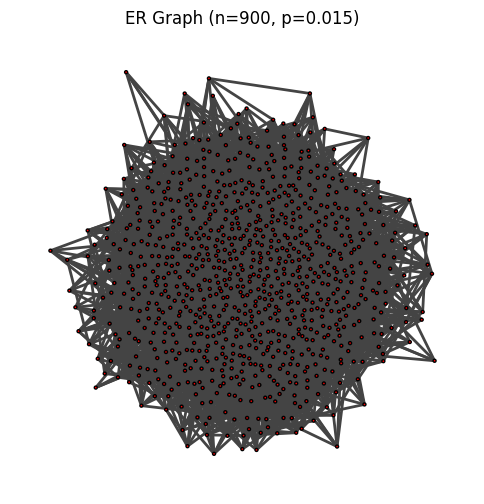

In [7]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Parameters
n = 900
p = 0.015

# Create ER graph
g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)

# Basic info
print(f"Connected: {g.is_connected()}")
print(f"Nodes: {g.vcount()} | Edges: {g.ecount()} | Mean degree: {np.mean(g.degree()):.3f}")

# Plot graph
fig, ax = plt.subplots(figsize=(6, 6))
ig.plot(g, target=ax, vertex_size=3, vertex_label=None)
ax.set_title(f"ER Graph (n={n}, p={p})")
plt.show()

1(b)

Connected: True
Nodes: 900 | Edges: 6132 | Mean degree: 13.627


/tmp/ipykernel_3851/2037629287.py:91: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  dists_from_start = g.shortest_paths(source=start_node)[0]


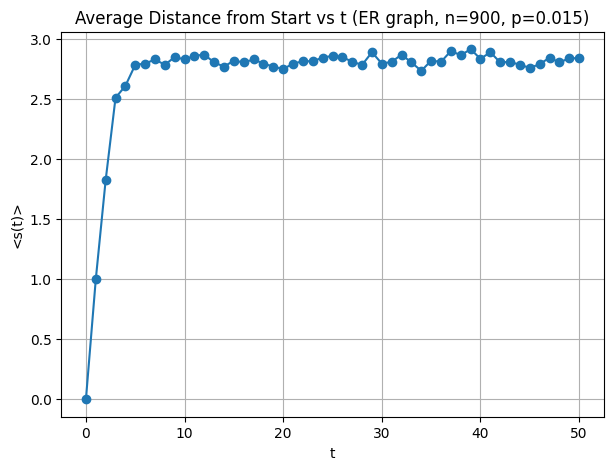

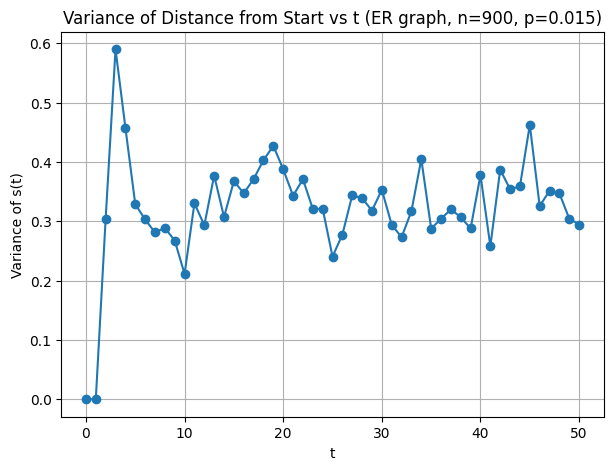

In [8]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helper: transition matrix
# -------------------------------------------------
def create_transition_matrix(g):
    n = g.vcount()
    P = np.zeros((n, n))

    for v in range(n):
        neighbors = g.neighbors(v, mode ="out")
        if len(neighbors) > 0:
            P[v, neighbors] = 1 / len(neighbors)
        else:
            P[v, :] = 1.0 / n   # just in case of isolated node

    return P

# -------------------------------------------------
# Helper: random walk
# -------------------------------------------------
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    """
    Random walk on a graph.
      teleport_prob:    probability of teleporting at each step (0 = no teleportation)
      teleport_weights: array of teleportation target probabilities (None = uniform)
      track_path:       if True, return full path; otherwise return final node
    """
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

# -------------------------------------------------
# 1(b): ER random walk
# -------------------------------------------------
np.random.seed(0)

n = 900
p = 0.015
num_steps = 50
num_trials = 200   # number of random starting nodes / walks

# Create graph from 1(a)
g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)

print(f"Connected: {g.is_connected()}")
print(f"Nodes: {g.vcount()} | Edges: {g.ecount()} | Mean degree: {np.mean(g.degree()):.3f}")

# Precompute transition matrix
P = create_transition_matrix(g)

# distances_over_trials[trial, t] = shortest-path distance from start to current node at step t
distances_over_trials = np.zeros((num_trials, num_steps + 1))

for trial in range(num_trials):
    start_node = np.random.randint(g.vcount())

    # full path of the walker
    path = random_walk(
        g,
        num_steps=num_steps,
        start_node=start_node,
        transition_matrix=P,
        teleport_prob=0.0,
        track_path=True
    )

    # shortest path distances from the start node to every node
    dists_from_start = g.shortest_paths(source=start_node)[0]

    # record distance from start at each step
    for t, v in enumerate(path):
        distances_over_trials[trial, t] = dists_from_start[v]

# Average distance and variance at each time t
mean_s_t = np.mean(distances_over_trials, axis=0)
var_s_t = np.var(distances_over_trials, axis=0)

# Time axis
t_vals = np.arange(num_steps + 1)

# Plot <s(t)> vs t
plt.figure(figsize=(7, 5))
plt.plot(t_vals, mean_s_t, marker='o')
plt.xlabel("t")
plt.ylabel("<s(t)>")
plt.title("Average Distance from Start vs t (ER graph, n=900, p=0.015)")
plt.grid(True)
plt.show()

# Plot variance vs t
plt.figure(figsize=(7, 5))
plt.plot(t_vals, var_s_t, marker='o')
plt.xlabel("t")
plt.ylabel("Variance of s(t)")
plt.title("Variance of Distance from Start vs t (ER graph, n=900, p=0.015)")
plt.grid(True)
plt.show()

1(c)

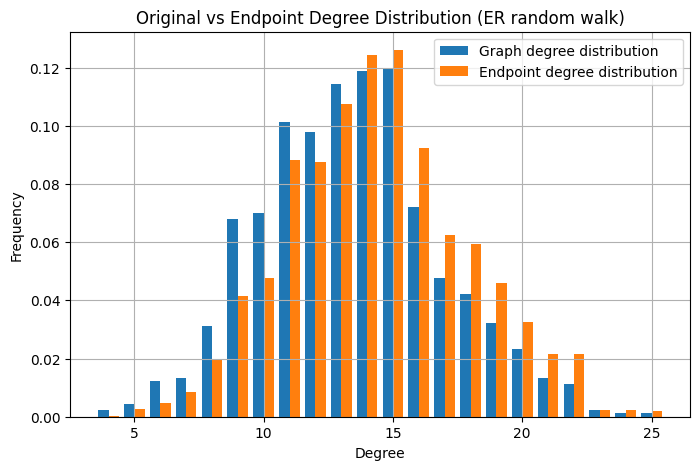

Mean degree of all nodes: 13.431
Mean degree of endpoint nodes: 14.365


In [9]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -------------------------------------------------
# Helper: transition matrix
# -------------------------------------------------
def create_transition_matrix(g):
    n = g.vcount()
    P = np.zeros((n, n))

    for v in range(n):
        neighbors = g.neighbors(v, mode ="out")
        if len(neighbors) > 0:
            P[v, neighbors] = 1 / len(neighbors)
        else:
            P[v, :] = 1.0 / n   # just in case of isolated node

    return P

# -------------------------------------------------
# Helper: random walk
# -------------------------------------------------
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

# -------------------------------------------------
# 1(c): degree distribution of endpoints
# -------------------------------------------------
np.random.seed(0)

n = 900
p = 0.015
num_steps = 50
num_trials = 5000

# graph from 1(a)
g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)
P = create_transition_matrix(g)

# Original graph degree distribution
deg_all = g.degree()
counts_all = Counter(deg_all)
k_all = np.array(sorted(counts_all.keys()))
freq_all = np.array([counts_all[k] / g.vcount() for k in k_all])

# Endpoint degree distribution
end_degrees = []

for _ in range(num_trials):
    start_node = np.random.randint(g.vcount())
    end_node = random_walk(
        g,
        num_steps=num_steps,
        start_node=start_node,
        transition_matrix=P,
        teleport_prob=0.0,
        track_path=False
    )
    end_degrees.append(g.degree(end_node))

counts_end = Counter(end_degrees)
k_end = np.array(sorted(counts_end.keys()))
freq_end = np.array([counts_end[k] / len(end_degrees) for k in k_end])

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(k_all - 0.2, freq_all, width=0.4, label="Graph degree distribution")
plt.bar(k_end + 0.2, freq_end, width=0.4, label="Endpoint degree distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Original vs Endpoint Degree Distribution (ER random walk)")
plt.legend()
plt.grid(True)
plt.show()

# Print means for comparison
print(f"Mean degree of all nodes: {np.mean(deg_all):.3f}")
print(f"Mean degree of endpoint nodes: {np.mean(end_degrees):.3f}")

1(d)

Connected: True
Nodes: 9000 | Edges: 608330 | Mean degree: 135.184
Diameter: 3


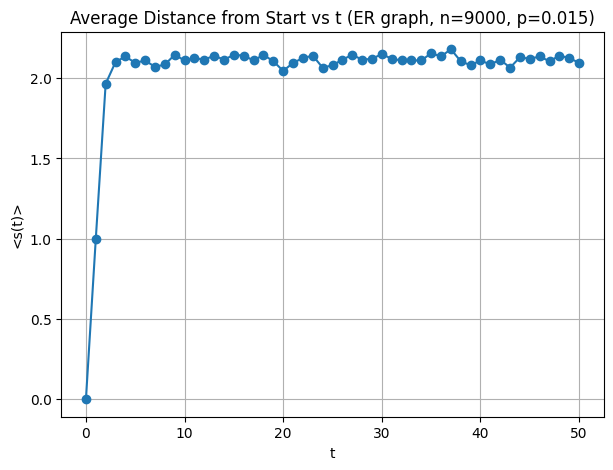

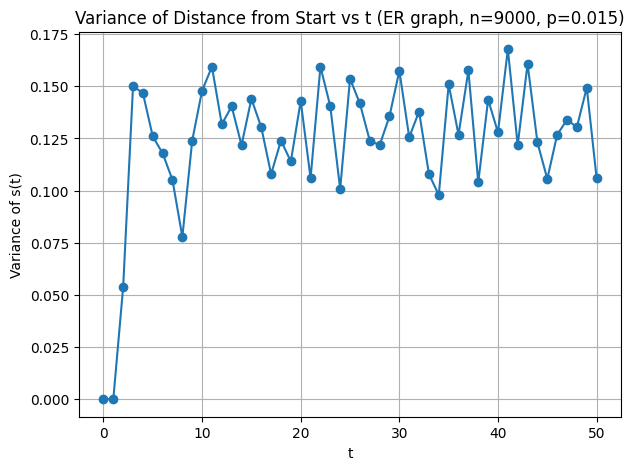

In [11]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helper: transition matrix
# -------------------------------------------------
def create_transition_matrix(g):
    n = g.vcount()
    P = np.zeros((n, n))

    for v in range(n):
        neighbors = g.neighbors(v, mode ="out")
        if len(neighbors) > 0:
            P[v, neighbors] = 1 / len(neighbors)
        else:
            P[v, :] = 1.0 / n   # just in case of isolated node

    return P

# -------------------------------------------------
# Helper: random walk
# -------------------------------------------------
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

# -------------------------------------------------
# 1(d): ER random walk with n = 9000
# -------------------------------------------------
np.random.seed(0)

n = 9000
p = 0.015
num_steps = 50
num_trials = 200

g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)

print(f"Connected: {g.is_connected()}")
print(f"Nodes: {g.vcount()} | Edges: {g.ecount()} | Mean degree: {np.mean(g.degree()):.3f}")
print(f"Diameter: {g.diameter()}")

P = create_transition_matrix(g)

distances_over_trials = np.zeros((num_trials, num_steps + 1))

for trial in range(num_trials):
    start_node = np.random.randint(g.vcount())
    path = random_walk(
        g,
        num_steps=num_steps,
        start_node=start_node,
        transition_matrix=P,
        teleport_prob=0.0,
        track_path=True
    )

    dists_from_start = g.distances(source=start_node)[0]

    for t, v in enumerate(path):
        distances_over_trials[trial, t] = dists_from_start[v]

mean_s_t = np.mean(distances_over_trials, axis=0)
var_s_t = np.var(distances_over_trials, axis=0)

t_vals = np.arange(num_steps + 1)

plt.figure(figsize=(7, 5))
plt.plot(t_vals, mean_s_t, marker='o')
plt.xlabel("t")
plt.ylabel("<s(t)>")
plt.title("Average Distance from Start vs t (ER graph, n=9000, p=0.015)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(t_vals, var_s_t, marker='o')
plt.xlabel("t")
plt.ylabel("Variance of s(t)")
plt.title("Variance of Distance from Start vs t (ER graph, n=9000, p=0.015)")
plt.grid(True)
plt.show()

2(a)

Connected: True
Nodes: 900 | Edges: 899 | Mean degree: 1.998


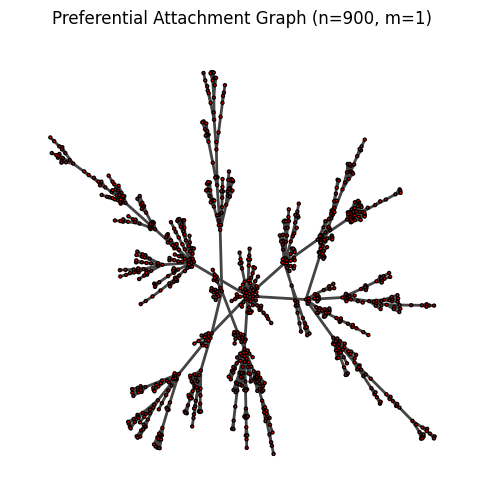

In [12]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 900
m = 1

# Generate preferential attachment graph
g_pa = ig.Graph.Barabasi(n=n, m=m, directed=False)

print(f"Connected: {g_pa.is_connected()}")
print(f"Nodes: {g_pa.vcount()} | Edges: {g_pa.ecount()} | Mean degree: {np.mean(g_pa.degree()):.3f}")

# Plot the graph
fig, ax = plt.subplots(figsize=(6, 6))
ig.plot(g_pa, target=ax, vertex_size=3, vertex_label=None)
ax.set_title(f"Preferential Attachment Graph (n={n}, m={m})")
plt.show()

2(b)

Connected: True
Nodes: 900 | Edges: 899 | Mean degree: 1.998
Diameter: 20


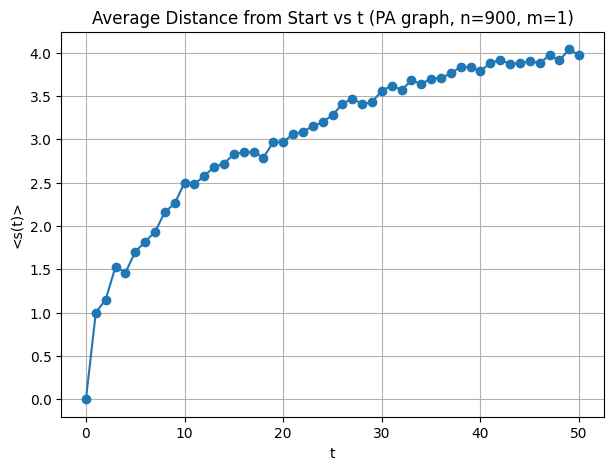

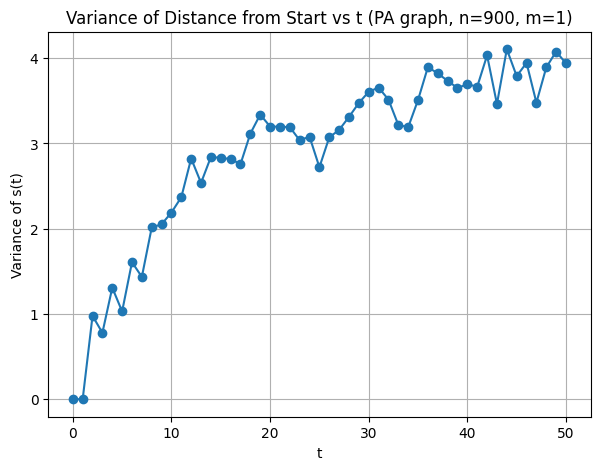

In [13]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helper: transition matrix
# -------------------------------------------------
def create_transition_matrix(g):
    n = g.vcount()
    P = np.zeros((n, n))

    for v in range(n):
        neighbors = g.neighbors(v, mode ="out")
        if len(neighbors) > 0:
            P[v, neighbors] = 1 / len(neighbors)
        else:
            P[v, :] = 1.0 / n   # just in case of isolated node

    return P


def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    """
    Random walk on a graph.
      teleport_prob:    probability of teleporting at each step (0 = no teleportation)
      teleport_weights: array of teleportation target probabilities (None = uniform)
      track_path:       if True, return full path; otherwise return final node
    """
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

# -------------------------------------------------
# 2(b): Random walk on PA graph
# -------------------------------------------------
np.random.seed(0)

n = 900
m = 1
num_steps = 50
num_trials = 200

# Graph from 2(a)
g_pa = ig.Graph.Barabasi(n=n, m=m, directed=False)

print(f"Connected: {g_pa.is_connected()}")
print(f"Nodes: {g_pa.vcount()} | Edges: {g_pa.ecount()} | Mean degree: {np.mean(g_pa.degree()):.3f}")
print(f"Diameter: {g_pa.diameter()}")

# Precompute transition matrix
P = create_transition_matrix(g_pa)

# distances_over_trials[trial, t] = shortest-path distance from start to current node at step t
distances_over_trials = np.zeros((num_trials, num_steps + 1))

for trial in range(num_trials):
    start_node = np.random.randint(g_pa.vcount())

    # Full path of the walker
    path = random_walk(
        g_pa,
        num_steps=num_steps,
        start_node=start_node,
        transition_matrix=P,
        teleport_prob=0.0,
        track_path=True
    )

    # Distances from the start node to every node
    dists_from_start = g_pa.distances(source=start_node)[0]

    # Record distance from start at each step
    for t, v in enumerate(path):
        distances_over_trials[trial, t] = dists_from_start[v]

# Average distance and variance at each time t
mean_s_t = np.mean(distances_over_trials, axis=0)
var_s_t = np.var(distances_over_trials, axis=0)

t_vals = np.arange(num_steps + 1)

# Plot <s(t)> vs t
plt.figure(figsize=(7, 5))
plt.plot(t_vals, mean_s_t, marker='o')
plt.xlabel("t")
plt.ylabel("<s(t)>")
plt.title("Average Distance from Start vs t (PA graph, n=900, m=1)")
plt.grid(True)
plt.show()

# Plot variance vs t
plt.figure(figsize=(7, 5))
plt.plot(t_vals, var_s_t, marker='o')
plt.xlabel("t")
plt.ylabel("Variance of s(t)")
plt.title("Variance of Distance from Start vs t (PA graph, n=900, m=1)")
plt.grid(True)
plt.show()

2(c)

Connected: True
Nodes: 900 | Edges: 899 | Mean degree: 1.998


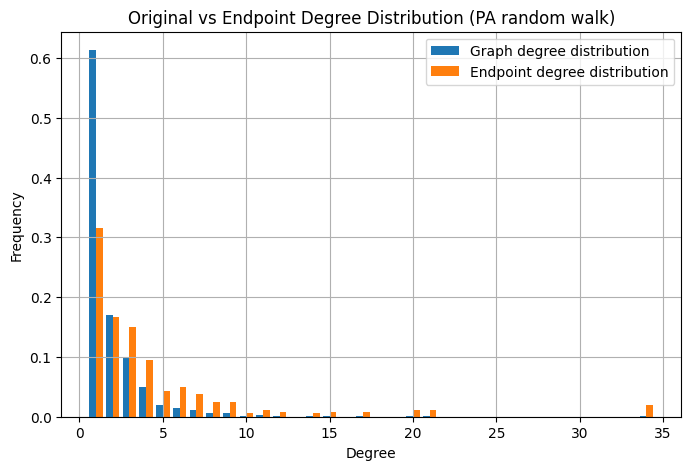

Mean degree of all nodes: 1.998
Mean degree of endpoint nodes: 4.456


In [14]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -------------------------------------------------
# Helper: transition matrix
# -------------------------------------------------
def create_transition_matrix(g):
    n = g.vcount()
    P = np.zeros((n, n))

    for v in range(n):
        neighbors = g.neighbors(v, mode ="out")
        if len(neighbors) > 0:
            P[v, neighbors] = 1 / len(neighbors)
        else:
            P[v, :] = 1.0 / n   # just in case of isolated node

    return P

# -------------------------------------------------
# Helper: random walk
# -------------------------------------------------
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

# -------------------------------------------------
# 2(c): endpoint degree distribution on PA graph
# -------------------------------------------------
np.random.seed(0)

n = 900
m = 1
num_steps = 50
num_trials = 5000

# Graph from 2(a)
g_pa = ig.Graph.Barabasi(n=n, m=m, directed=False)
P = create_transition_matrix(g_pa)

print(f"Connected: {g_pa.is_connected()}")
print(f"Nodes: {g_pa.vcount()} | Edges: {g_pa.ecount()} | Mean degree: {np.mean(g_pa.degree()):.3f}")

# Original graph degree distribution
deg_all = g_pa.degree()
counts_all = Counter(deg_all)
k_all = np.array(sorted(counts_all.keys()))
freq_all = np.array([counts_all[k] / g_pa.vcount() for k in k_all])

# Endpoint degree distribution
end_degrees = []

for _ in range(num_trials):
    start_node = np.random.randint(g_pa.vcount())
    end_node = random_walk(
        g_pa,
        num_steps=num_steps,
        start_node=start_node,
        transition_matrix=P,
        teleport_prob=0.0,
        track_path=False
    )
    end_degrees.append(g_pa.degree(end_node))

counts_end = Counter(end_degrees)
k_end = np.array(sorted(counts_end.keys()))
freq_end = np.array([counts_end[k] / len(end_degrees) for k in k_end])

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(k_all - 0.2, freq_all, width=0.4, label="Graph degree distribution")
plt.bar(k_end + 0.2, freq_end, width=0.4, label="Endpoint degree distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Original vs Endpoint Degree Distribution (PA random walk)")
plt.legend()
plt.grid(True)
plt.show()

# Compare average degree
print(f"Mean degree of all nodes: {np.mean(deg_all):.3f}")
print(f"Mean degree of endpoint nodes: {np.mean(end_degrees):.3f}")

2(d)

n=90   | Mean degree=1.978 | Diameter=9
n=900  | Mean degree=1.998 | Diameter=22
n=9000 | Mean degree=2.000 | Diameter=29


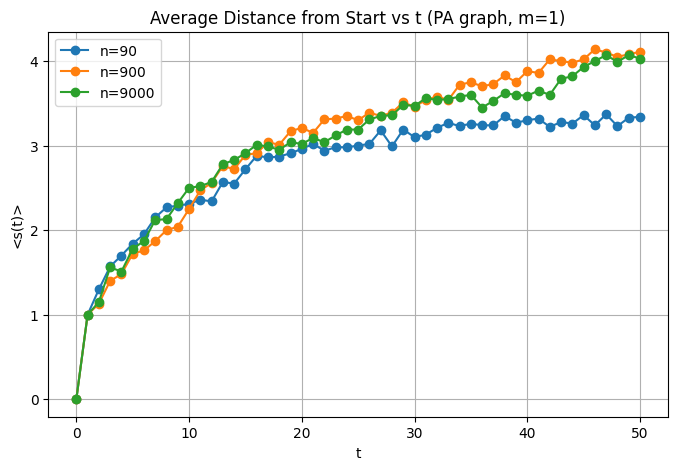

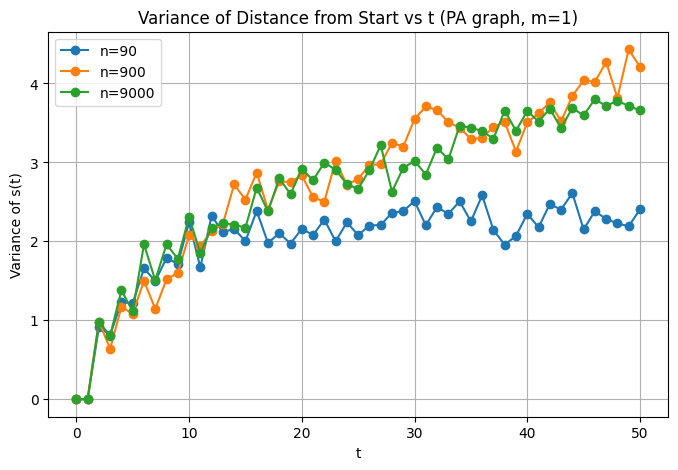

In [15]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helper: transition matrix
# -------------------------------------------------
def create_transition_matrix(g):
    n = g.vcount()
    P = np.zeros((n, n))

    for v in range(n):
        neighbors = g.neighbors(v, mode ="out")
        if len(neighbors) > 0:
            P[v, neighbors] = 1 / len(neighbors)
        else:
            P[v, :] = 1.0 / n   # just in case of isolated node

    return P

# -------------------------------------------------
# Helper: random walk
# -------------------------------------------------
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

# -------------------------------------------------
# Compute <s(t)> and Var[s(t)] for a PA graph
# -------------------------------------------------
def compute_pa_rw_distance_stats(n, m=1, num_steps=50, num_trials=200, seed=0):
    np.random.seed(seed)

    g = ig.Graph.Barabasi(n=n, m=m, directed=False)
    P = create_transition_matrix(g)

    distances_over_trials = np.zeros((num_trials, num_steps + 1))

    for trial in range(num_trials):
        start_node = np.random.randint(g.vcount())

        path = random_walk(
            g,
            num_steps=num_steps,
            start_node=start_node,
            transition_matrix=P,
            teleport_prob=0.0,
            track_path=True
        )

        dists_from_start = g.distances(source=start_node)[0]

        for t, v in enumerate(path):
            distances_over_trials[trial, t] = dists_from_start[v]

    mean_s_t = np.mean(distances_over_trials, axis=0)
    var_s_t = np.var(distances_over_trials, axis=0)

    return g, mean_s_t, var_s_t

# -------------------------------------------------
# Run for n = 90, 900, 9000
# -------------------------------------------------
num_steps = 50
num_trials = 200
m = 1

g_90, mean_90, var_90 = compute_pa_rw_distance_stats(90, m=m, num_steps=num_steps, num_trials=num_trials, seed=0)
g_900, mean_900, var_900 = compute_pa_rw_distance_stats(900, m=m, num_steps=num_steps, num_trials=num_trials, seed=1)
g_9000, mean_9000, var_9000 = compute_pa_rw_distance_stats(9000, m=m, num_steps=num_steps, num_trials=num_trials, seed=2)

t_vals = np.arange(num_steps + 1)

# Print graph stats
print(f"n=90   | Mean degree={np.mean(g_90.degree()):.3f} | Diameter={g_90.diameter()}")
print(f"n=900  | Mean degree={np.mean(g_900.degree()):.3f} | Diameter={g_900.diameter()}")
print(f"n=9000 | Mean degree={np.mean(g_9000.degree()):.3f} | Diameter={g_9000.diameter()}")

# Plot <s(t)>
plt.figure(figsize=(8, 5))
plt.plot(t_vals, mean_90, marker='o', label="n=90")
plt.plot(t_vals, mean_900, marker='o', label="n=900")
plt.plot(t_vals, mean_9000, marker='o', label="n=9000")
plt.xlabel("t")
plt.ylabel("<s(t)>")
plt.title("Average Distance from Start vs t (PA graph, m=1)")
plt.legend()
plt.grid(True)
plt.show()

# Plot Var[s(t)]
plt.figure(figsize=(8, 5))
plt.plot(t_vals, var_90, marker='o', label="n=90")
plt.plot(t_vals, var_900, marker='o', label="n=900")
plt.plot(t_vals, var_9000, marker='o', label="n=9000")
plt.xlabel("t")
plt.ylabel("Variance of s(t)")
plt.title("Variance of Distance from Start vs t (PA graph, m=1)")
plt.legend()
plt.grid(True)
plt.show()

3(a)

Nodes: 900 | Edges: 7180
Mean in-degree: 7.978
Mean out-degree: 7.978

Top 10 visited nodes:
Node 0: visit_prob=0.067890, in-degree=271, out-degree=4, total-degree=275
Node 141: visit_prob=0.063260, in-degree=245, out-degree=5, total-degree=250
Node 570: visit_prob=0.050835, in-degree=272, out-degree=8, total-degree=280
Node 492: visit_prob=0.048320, in-degree=193, out-degree=4, total-degree=197
Node 2: visit_prob=0.045060, in-degree=268, out-degree=6, total-degree=274
Node 1: visit_prob=0.037910, in-degree=189, out-degree=5, total-degree=194
Node 6: visit_prob=0.036660, in-degree=194, out-degree=8, total-degree=202
Node 3: visit_prob=0.036360, in-degree=208, out-degree=7, total-degree=215
Node 409: visit_prob=0.034740, in-degree=209, out-degree=6, total-degree=215
Node 31: visit_prob=0.028590, in-degree=209, out-degree=7, total-degree=216


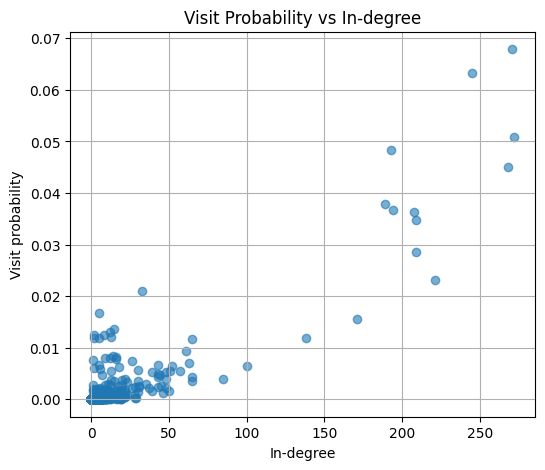

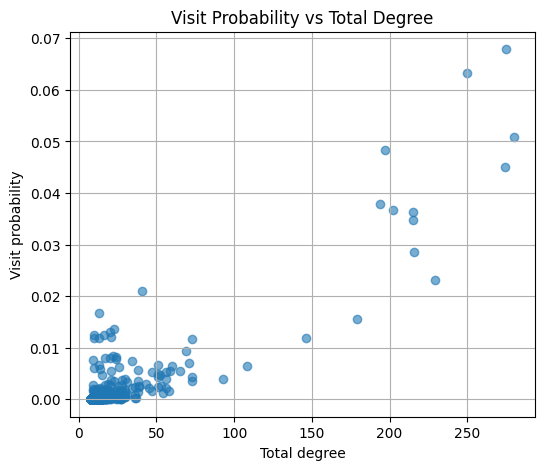

In [16]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

def create_merged_pa_network(n, m):
    """Create a directed PA network with shuffled edges from a second PA network merged in."""
    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

def random_walk_directed_safe(g, num_steps, start_node, track_path=False):
    """
    Directed random walk without teleportation.
    If a node has no outgoing edges, jump uniformly to a random node.
    """
    n = g.vcount()
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        out_neighbors = g.neighbors(v, mode="out")

        if len(out_neighbors) > 0:
            v = int(np.random.choice(out_neighbors))
        else:
            # Dangling node: jump uniformly
            v = int(np.random.randint(n))

        if track_path:
            path.append(v)

    if track_path:
        return path
    return v


np.random.seed(0)

# Problem 3(a) parameters
n = 900
m = 4
num_steps = 200000

# Create merged network
g_pr = create_merged_pa_network(n, m)

print(f"Nodes: {g_pr.vcount()} | Edges: {g_pr.ecount()}")

# Degree information
in_deg = np.array(g_pr.degree(mode="in"))
out_deg = np.array(g_pr.degree(mode="out"))
total_deg = np.array(g_pr.degree(mode="all"))

print(f"Mean in-degree: {np.mean(in_deg):.3f}")
print(f"Mean out-degree: {np.mean(out_deg):.3f}")

# Random walk simulation
start_node = np.random.randint(n)
path = random_walk_directed_safe(
    g_pr,
    num_steps=num_steps,
    start_node=start_node,
    track_path=True
)

# Visit counts
visit_counts = np.zeros(n)
for v in path:
    visit_counts[v] += 1

visit_prob = visit_counts / visit_counts.sum()

# Top visited nodes
top_idx = np.argsort(visit_prob)[::-1][:10]
print("\nTop 10 visited nodes:")
for idx in top_idx:
    print(
        f"Node {idx}: visit_prob={visit_prob[idx]:.6f}, "
        f"in-degree={in_deg[idx]}, out-degree={out_deg[idx]}, total-degree={total_deg[idx]}"
    )

# Scatter: visit probability vs in-degree
plt.figure(figsize=(6, 5))
plt.scatter(in_deg, visit_prob, alpha=0.6)
plt.xlabel("In-degree")
plt.ylabel("Visit probability")
plt.title("Visit Probability vs In-degree")
plt.grid(True)
plt.show()

# Scatter: visit probability vs total degree
plt.figure(figsize=(6, 5))
plt.scatter(total_deg, visit_prob, alpha=0.6)
plt.xlabel("Total degree")
plt.ylabel("Visit probability")
plt.title("Visit Probability vs Total Degree")
plt.grid(True)
plt.show()

3(b)

Nodes: 900 | Edges: 7180
Mean in-degree: 7.978
Mean out-degree: 7.978

Top 10 visited nodes with teleportation:
Node 1: visit_prob=0.046865, in-degree=187, out-degree=5, total-degree=192
Node 2: visit_prob=0.042585, in-degree=312, out-degree=6, total-degree=318
Node 0: visit_prob=0.042515, in-degree=221, out-degree=4, total-degree=225
Node 492: visit_prob=0.042145, in-degree=276, out-degree=4, total-degree=280
Node 31: visit_prob=0.038235, in-degree=270, out-degree=7, total-degree=277
Node 141: visit_prob=0.035500, in-degree=206, out-degree=5, total-degree=211
Node 409: visit_prob=0.029820, in-degree=199, out-degree=6, total-degree=205
Node 7: visit_prob=0.026220, in-degree=253, out-degree=8, total-degree=261
Node 3: visit_prob=0.025490, in-degree=173, out-degree=7, total-degree=180
Node 570: visit_prob=0.025400, in-degree=127, out-degree=8, total-degree=135


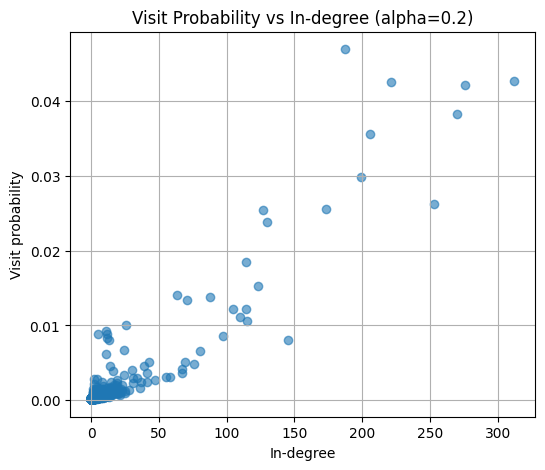

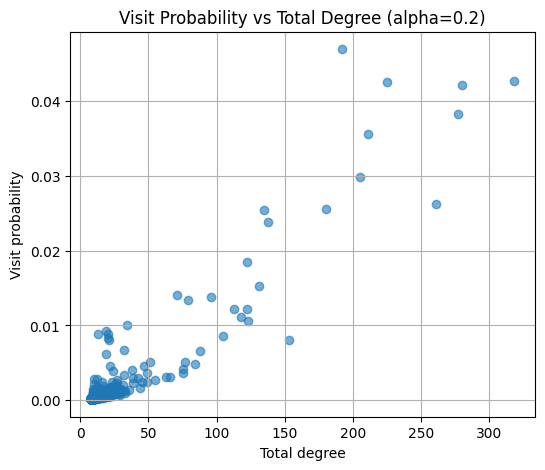

In [17]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

def create_merged_pa_network(n, m):
    """Create a directed PA network with shuffled edges from a second PA network merged in."""
    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

def random_walk_directed_with_teleport(g, num_steps, start_node, alpha=0.2, track_path=False):
    """
    Directed random walk with teleportation.
    With probability alpha, jump uniformly to a random node.
    Otherwise, follow a uniformly random outgoing edge.
    If a node has no outgoing edges, jump uniformly to a random node.
    """
    n = g.vcount()
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if np.random.random() < alpha:
            v = int(np.random.randint(n))
        else:
            out_neighbors = g.neighbors(v, mode="out")
            if len(out_neighbors) > 0:
                v = int(np.random.choice(out_neighbors))
            else:
                v = int(np.random.randint(n))

        if track_path:
            path.append(v)

    if track_path:
        return path
    return v


np.random.seed(0)

# Problem 3(b) parameters
n = 900
m = 4
alpha = 0.2
num_steps = 200000

# Build graph
g_pr = create_merged_pa_network(n, m)

print(f"Nodes: {g_pr.vcount()} | Edges: {g_pr.ecount()}")

# Degree information
in_deg = np.array(g_pr.degree(mode="in"))
out_deg = np.array(g_pr.degree(mode="out"))
total_deg = np.array(g_pr.degree(mode="all"))

print(f"Mean in-degree: {np.mean(in_deg):.3f}")
print(f"Mean out-degree: {np.mean(out_deg):.3f}")

# Run random walk with teleportation
start_node = np.random.randint(n)
path = random_walk_directed_with_teleport(
    g_pr,
    num_steps=num_steps,
    start_node=start_node,
    alpha=alpha,
    track_path=True
)

# Visit probability
visit_counts = np.zeros(n)
for v in path:
    visit_counts[v] += 1

visit_prob = visit_counts / visit_counts.sum()

# Top visited nodes
top_idx = np.argsort(visit_prob)[::-1][:10]
print("\nTop 10 visited nodes with teleportation:")
for idx in top_idx:
    print(
        f"Node {idx}: visit_prob={visit_prob[idx]:.6f}, "
        f"in-degree={in_deg[idx]}, out-degree={out_deg[idx]}, total-degree={total_deg[idx]}"
    )

# Scatter plots
plt.figure(figsize=(6, 5))
plt.scatter(in_deg, visit_prob, alpha=0.6)
plt.xlabel("In-degree")
plt.ylabel("Visit probability")
plt.title(f"Visit Probability vs In-degree (alpha={alpha})")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(total_deg, visit_prob, alpha=0.6)
plt.xlabel("Total degree")
plt.ylabel("Visit probability")
plt.title(f"Visit Probability vs Total Degree (alpha={alpha})")
plt.grid(True)
plt.show()

4(a)

Nodes: 900 | Edges: 7180
Sum of PageRank weights: 1.000000

Top 10 visited nodes under personalized PageRank teleportation:
Node 492: visit_prob=0.065815, PageRank=0.049614, in-degree=201, out-degree=4, total-degree=205
Node 1: visit_prob=0.059115, PageRank=0.045958, in-degree=250, out-degree=5, total-degree=255
Node 31: visit_prob=0.048265, PageRank=0.036579, in-degree=185, out-degree=7, total-degree=192
Node 2: visit_prob=0.047120, PageRank=0.037790, in-degree=237, out-degree=6, total-degree=243
Node 409: visit_prob=0.044845, PageRank=0.035583, in-degree=230, out-degree=6, total-degree=236
Node 141: visit_prob=0.044680, PageRank=0.037000, in-degree=280, out-degree=5, total-degree=285
Node 0: visit_prob=0.044485, PageRank=0.034569, in-degree=198, out-degree=4, total-degree=202
Node 3: visit_prob=0.040965, PageRank=0.033316, in-degree=225, out-degree=7, total-degree=232
Node 570: visit_prob=0.037490, PageRank=0.032201, in-degree=279, out-degree=8, total-degree=287
Node 272: visit_prob=

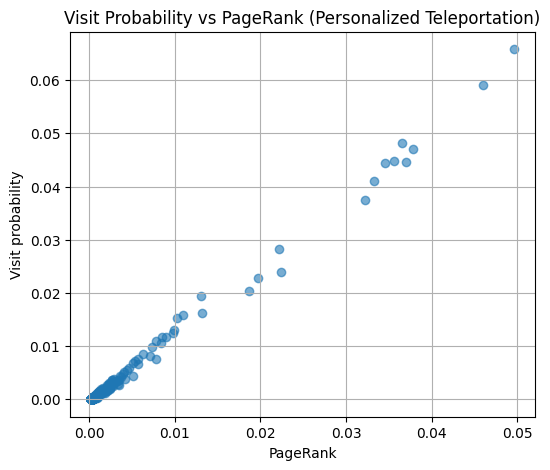

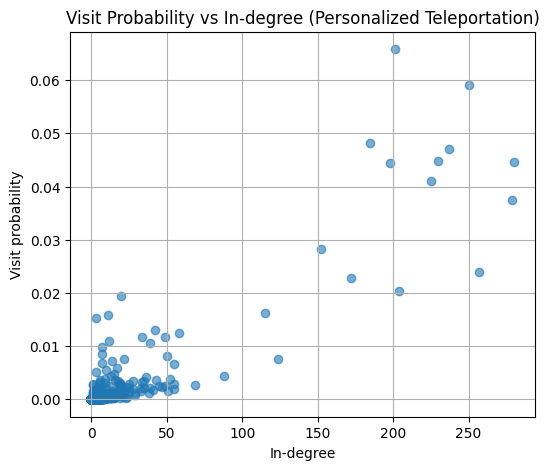

In [18]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

def create_merged_pa_network(n, m):
    """Create a directed PA network with shuffled edges from a second PA network merged in."""
    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

def random_walk_directed_personalized(g, num_steps, start_node, alpha=0.2,
                                      teleport_weights=None, track_path=False):
    """
    Directed random walk with teleportation.
    With probability alpha, teleport according to teleport_weights.
    Otherwise, follow a uniformly random outgoing edge.
    If a node has no outgoing edges, teleport according to teleport_weights.
    """
    n = g.vcount()
    nodes = np.arange(n)

    if teleport_weights is None:
        teleport_weights = np.ones(n) / n
    else:
        teleport_weights = np.array(teleport_weights, dtype=float)
        teleport_weights = teleport_weights / teleport_weights.sum()

    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if np.random.random() < alpha:
            v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            out_neighbors = g.neighbors(v, mode="out")
            if len(out_neighbors) > 0:
                v = int(np.random.choice(out_neighbors))
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))

        if track_path:
            path.append(v)

    if track_path:
        return path
    return v


np.random.seed(0)

# Problem parameters
n = 900
m = 4
alpha = 0.2
num_steps = 200000

# Create graph
g_pr = create_merged_pa_network(n, m)

print(f"Nodes: {g_pr.vcount()} | Edges: {g_pr.ecount()}")

# Degree information
in_deg = np.array(g_pr.degree(mode="in"))
out_deg = np.array(g_pr.degree(mode="out"))
total_deg = np.array(g_pr.degree(mode="all"))

# Step 1: compute ordinary PageRank
# In igraph, damping is usually 1 - alpha
pr = np.array(g_pr.pagerank(damping=1 - alpha, directed=True))
pr = pr / pr.sum()

print(f"Sum of PageRank weights: {pr.sum():.6f}")

# Step 2: random walk with teleportation weighted by PageRank
start_node = np.random.randint(n)
path_ppr = random_walk_directed_personalized(
    g_pr,
    num_steps=num_steps,
    start_node=start_node,
    alpha=alpha,
    teleport_weights=pr,
    track_path=True
)

# Step 3: estimate visit probabilities
visit_counts_ppr = np.zeros(n)
for v in path_ppr:
    visit_counts_ppr[v] += 1

visit_prob_ppr = visit_counts_ppr / visit_counts_ppr.sum()

# Top visited nodes
top_idx = np.argsort(visit_prob_ppr)[::-1][:10]
print("\nTop 10 visited nodes under personalized PageRank teleportation:")
for idx in top_idx:
    print(
        f"Node {idx}: visit_prob={visit_prob_ppr[idx]:.6f}, "
        f"PageRank={pr[idx]:.6f}, "
        f"in-degree={in_deg[idx]}, out-degree={out_deg[idx]}, total-degree={total_deg[idx]}"
    )

# Scatter: visit probability vs PageRank
plt.figure(figsize=(6, 5))
plt.scatter(pr, visit_prob_ppr, alpha=0.6)
plt.xlabel("PageRank")
plt.ylabel("Visit probability")
plt.title("Visit Probability vs PageRank (Personalized Teleportation)")
plt.grid(True)
plt.show()

# Scatter: visit probability vs in-degree
plt.figure(figsize=(6, 5))
plt.scatter(in_deg, visit_prob_ppr, alpha=0.6)
plt.xlabel("In-degree")
plt.ylabel("Visit probability")
plt.title("Visit Probability vs In-degree (Personalized Teleportation)")
plt.grid(True)
plt.show()

4(b)

Nodes: 900 | Edges: 7180

Two median-PageRank nodes:
Node 794: original PageRank = 0.000274
Node 403: original PageRank = 0.000274

Top 10 visited nodes under 2-node teleportation:
Node 794: new_visit_prob=0.100959, original_PR=0.000274
Node 403: new_visit_prob=0.100064, original_PR=0.000274
Node 492: new_visit_prob=0.055835, original_PR=0.049277
Node 0: new_visit_prob=0.051135, original_PR=0.050104
Node 2: new_visit_prob=0.048000, original_PR=0.052043
Node 141: new_visit_prob=0.045900, original_PR=0.040667
Node 1: new_visit_prob=0.042375, original_PR=0.047488
Node 409: new_visit_prob=0.032005, original_PR=0.023116
Node 570: new_visit_prob=0.020735, original_PR=0.015998
Node 272: new_visit_prob=0.020630, original_PR=0.014150

Teleportation nodes after personalization:
Node 794: new_visit_prob=0.100959, original_PR=0.000274
Node 403: new_visit_prob=0.100064, original_PR=0.000274


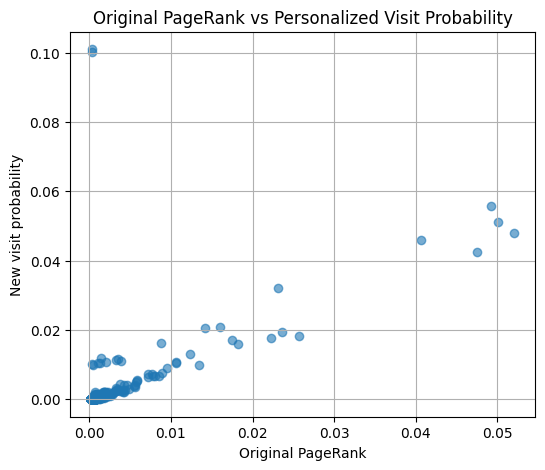

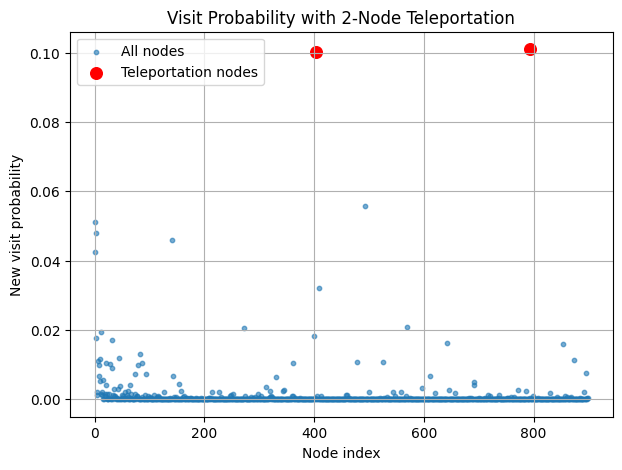

In [19]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

def create_merged_pa_network(n, m):
    """Create a directed PA network with shuffled edges from a second PA network merged in."""
    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

def random_walk_directed_personalized(g, num_steps, start_node, alpha=0.2,
                                      teleport_weights=None, track_path=False):
    """
    Directed random walk with personalized teleportation.
    With probability alpha, teleport according to teleport_weights.
    Otherwise, follow a uniformly random outgoing edge.
    If a node has no outgoing edges, teleport according to teleport_weights.
    """
    n = g.vcount()
    nodes = np.arange(n)

    if teleport_weights is None:
        teleport_weights = np.ones(n) / n
    else:
        teleport_weights = np.array(teleport_weights, dtype=float)
        teleport_weights = teleport_weights / teleport_weights.sum()

    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if np.random.random() < alpha:
            v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            out_neighbors = g.neighbors(v, mode="out")
            if len(out_neighbors) > 0:
                v = int(np.random.choice(out_neighbors))
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))

        if track_path:
            path.append(v)

    if track_path:
        return path
    return v


np.random.seed(0)

# Parameters
n = 900
m = 4
alpha = 0.2
num_steps = 200000

# Create graph
g_pr = create_merged_pa_network(n, m)

print(f"Nodes: {g_pr.vcount()} | Edges: {g_pr.ecount()}")

# Original PageRank (regular PageRank with uniform teleportation)
pr = np.array(g_pr.pagerank(damping=1 - alpha, directed=True))
pr = pr / pr.sum()

# Find two nodes with median PageRanks
sorted_idx = np.argsort(pr)
mid1 = sorted_idx[n // 2 - 1]
mid2 = sorted_idx[n // 2]

print("\nTwo median-PageRank nodes:")
print(f"Node {mid1}: original PageRank = {pr[mid1]:.6f}")
print(f"Node {mid2}: original PageRank = {pr[mid2]:.6f}")

# Teleport only to these two nodes with probabilities 1/2, 1/2
teleport_weights = np.zeros(n)
teleport_weights[mid1] = 0.5
teleport_weights[mid2] = 0.5

# Run personalized random walk
start_node = np.random.randint(n)
path = random_walk_directed_personalized(
    g_pr,
    num_steps=num_steps,
    start_node=start_node,
    alpha=alpha,
    teleport_weights=teleport_weights,
    track_path=True
)

# Estimate new personalized PageRank / visit probability
visit_counts = np.zeros(n)
for v in path:
    visit_counts[v] += 1
visit_prob = visit_counts / visit_counts.sum()

# Print top visited nodes
top_idx = np.argsort(visit_prob)[::-1][:10]
print("\nTop 10 visited nodes under 2-node teleportation:")
for idx in top_idx:
    print(
        f"Node {idx}: new_visit_prob={visit_prob[idx]:.6f}, "
        f"original_PR={pr[idx]:.6f}"
    )

# Print the two teleportation nodes again for emphasis
print("\nTeleportation nodes after personalization:")
print(f"Node {mid1}: new_visit_prob={visit_prob[mid1]:.6f}, original_PR={pr[mid1]:.6f}")
print(f"Node {mid2}: new_visit_prob={visit_prob[mid2]:.6f}, original_PR={pr[mid2]:.6f}")

# Plot 1: original PR vs new personalized visit probability
plt.figure(figsize=(6, 5))
plt.scatter(pr, visit_prob, alpha=0.6)
plt.xlabel("Original PageRank")
plt.ylabel("New visit probability")
plt.title("Original PageRank vs Personalized Visit Probability")
plt.grid(True)
plt.show()

# Plot 2: highlight the two teleportation nodes
plt.figure(figsize=(7, 5))
plt.scatter(np.arange(n), visit_prob, s=10, alpha=0.6, label="All nodes")
plt.scatter(
    [mid1, mid2],
    [visit_prob[mid1], visit_prob[mid2]],
    color="red",
    s=70,
    label="Teleportation nodes"
)
plt.xlabel("Node index")
plt.ylabel("New visit probability")
plt.title("Visit Probability with 2-Node Teleportation")
plt.legend()
plt.grid(True)
plt.show()

4(c)

Nodes: 900 | Edges: 7180

Trusted nodes:
Node 63: personalized PageRank = 0.100029
Node 263: personalized PageRank = 0.100001

Pearson r between visiting probability and personalized PageRank: 1.0000
p-value: 0.0000e+00

Top 10 visited nodes:
Node 263: visit_prob=0.100904, personalized_PR=0.100001
Node 63: visit_prob=0.099890, personalized_PR=0.100029
Node 0: visit_prob=0.055870, personalized_PR=0.055386
Node 1: visit_prob=0.054840, personalized_PR=0.054866
Node 141: visit_prob=0.052550, personalized_PR=0.051979
Node 492: visit_prob=0.041385, personalized_PR=0.041727
Node 570: visit_prob=0.041330, personalized_PR=0.041139
Node 2: visit_prob=0.040505, personalized_PR=0.040912
Node 4: visit_prob=0.037045, personalized_PR=0.037173
Node 409: visit_prob=0.029040, personalized_PR=0.028845


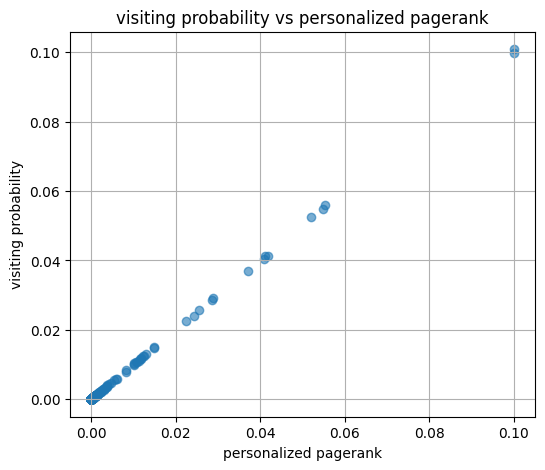

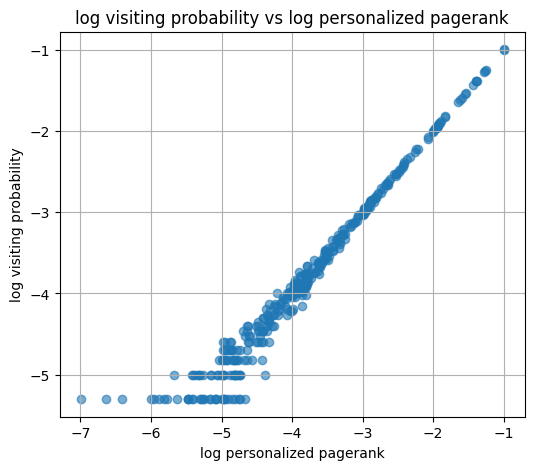

In [20]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def create_merged_pa_network(n, m, seed=0):
    np.random.seed(seed)

    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

def random_walk_directed_personalized(
    g,
    num_steps,
    start_node,
    alpha=0.2,
    teleport_weights=None,
    track_path=False
):
    n = g.vcount()
    nodes = np.arange(n)

    if teleport_weights is None:
        teleport_weights = np.ones(n) / n
    else:
        teleport_weights = np.array(teleport_weights, dtype=float)
        teleport_weights = teleport_weights / teleport_weights.sum()

    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if np.random.random() < alpha:
            v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            out_neighbors = g.neighbors(v, mode="out")
            if len(out_neighbors) > 0:
                v = int(np.random.choice(out_neighbors))
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))

        if track_path:
            path.append(v)

    if track_path:
        return path
    return v


# =========================
# 4(c) parameters
# =========================
n = 900
m = 4
alpha = 0.2
damping = 1 - alpha
num_steps = 200000
seed = 0

# Build the same style of graph as before
g = create_merged_pa_network(n, m, seed=seed)

print(f"Nodes: {g.vcount()} | Edges: {g.ecount()}")

trusted_nodes = [63, 263]

# Personalized PageRank from igraph
# reset_vertices means teleport only to these nodes
ppr = np.array(
    g.personalized_pagerank(
        damping=damping,
        reset_vertices=trusted_nodes,
        directed=True
    )
)
ppr = ppr / ppr.sum()

print("\nTrusted nodes:")
for v in trusted_nodes:
    print(f"Node {v}: personalized PageRank = {ppr[v]:.6f}")

# Build teleportation weights explicitly for simulation
teleport_weights = np.zeros(n)
teleport_weights[trusted_nodes[0]] = 0.5
teleport_weights[trusted_nodes[1]] = 0.5

# Random-walk estimate of visiting probability
np.random.seed(seed)
start_node = np.random.randint(n)
path = random_walk_directed_personalized(
    g,
    num_steps=num_steps,
    start_node=start_node,
    alpha=alpha,
    teleport_weights=teleport_weights,
    track_path=True
)

visit_counts = np.zeros(n)
for v in path:
    visit_counts[v] += 1
visit_prob = visit_counts / visit_counts.sum()

# Correlation
pearson_r, pearson_p = stats.pearsonr(visit_prob, ppr)
print(f"\nPearson r between visiting probability and personalized PageRank: {pearson_r:.4f}")
print(f"p-value: {pearson_p:.4e}")

# Show top nodes
top_idx = np.argsort(visit_prob)[::-1][:10]
print("\nTop 10 visited nodes:")
for idx in top_idx:
    print(
        f"Node {idx}: "
        f"visit_prob={visit_prob[idx]:.6f}, "
        f"personalized_PR={ppr[idx]:.6f}"
    )

# Plot 1: visit probability vs personalized pagerank
plt.figure(figsize=(6, 5))
plt.scatter(ppr, visit_prob, alpha=0.6)
plt.xlabel("personalized pagerank")
plt.ylabel("visiting probability")
plt.title("visiting probability vs personalized pagerank")
plt.grid(True)
plt.show()

# Plot 2: log-log version, like many reports show
mask = (ppr > 0) & (visit_prob > 0)
plt.figure(figsize=(6, 5))
plt.scatter(np.log10(ppr[mask]), np.log10(visit_prob[mask]), alpha=0.6)
plt.xlabel("log personalized pagerank")
plt.ylabel("log visiting probability")
plt.title("log visiting probability vs log personalized pagerank")
plt.grid(True)
plt.show()